# Eixo 4 — Estilo de Vida e Prevenção

Nesta seção, investigamos como a atividade física (`PhysActivity`) e o consumo regular de frutas (`Fruits`) e vegetais (`Veggies`) interagem e se associam à prevalência observada de **Diabetes** (`Diabetes_binary`) e **Hipertensão** (`HighBP`).

A pergunta clínica central é: **A prática de atividade física regular neutraliza o impacto da má alimentação na prevalência de diabetes e hipertensão?**

> **Nota metodológica:** O BRFSS 2015 é um estudo observacional transversal baseado em autorrelato. As análises descrevem **prevalência e associação estatística**, e não risco prospectivo ou causalidade.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)

df = pd.read_csv("../../diabetes_binary_health_indicators_BRFSS2015.csv")

variaveis_eixo4 = ["PhysActivity", "Fruits", "Veggies", "Diabetes_binary", "HighBP"]
variaveis_ausentes = [v for v in variaveis_eixo4 if v not in df.columns]
if variaveis_ausentes:
    raise ValueError(f"Variáveis ausentes no dataset: {variaveis_ausentes}")

print(f"Dimensões analisadas: {df[variaveis_eixo4].shape[0]:,} linhas x {df[variaveis_eixo4].shape[1]} colunas")
df[variaveis_eixo4].head()

Dimensões analisadas: 253,680 linhas x 5 colunas


,PhysActivity,Fruits,Veggies,Diabetes_binary,HighBP
0,0.0,0.0,1.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,1.0
3,1.0,1.0,1.0,0.0,1.0
4,1.0,1.0,1.0,0.0,1.0


In [2]:
df_eixo4 = df.copy()

# Classificação da dieta: 1 se consome Frutas E Vegetais ao menos 1x/dia, 0 caso contrário
df_eixo4["Dieta_Adequada"] = ((df_eixo4["Fruits"] == 1) & (df_eixo4["Veggies"] == 1)).astype(int)

# Construção dos 4 perfis comportamentais
def definir_perfil(row):
    ativo = row["PhysActivity"] == 1
    dieta = row["Dieta_Adequada"] == 1
    if ativo and dieta:
        return "Ativo + Dieta Adequada"
    elif ativo and not dieta:
        return "Ativo + Dieta Inadequada"
    elif not ativo and dieta:
        return "Sedentário + Dieta Adequada"
    else:
        return "Sedentário + Dieta Inadequada"

df_eixo4["Perfil_Estilo_Vida"] = df_eixo4.apply(definir_perfil, axis=1)

ordem_perfis = [
    "Ativo + Dieta Adequada",
    "Ativo + Dieta Inadequada",
    "Sedentário + Dieta Adequada",
    "Sedentário + Dieta Inadequada"
]

resumo_perfis = df_eixo4.groupby("Perfil_Estilo_Vida", observed=False).agg(
    n=("Diabetes_binary", "size"),
    Prev_Diabetes=("Diabetes_binary", "mean"),
    Prev_HighBP=("HighBP", "mean")
).loc[ordem_perfis].reset_index()

resumo_perfis["Distribuição Amostral (%)"] = (resumo_perfis["n"] / len(df_eixo4) * 100).round(2)
resumo_perfis["Prevalência de diabetes (%)"] = (resumo_perfis["Prev_Diabetes"] * 100).round(2)
resumo_perfis["Prevalência de hipertensão (%)"] = (resumo_perfis["Prev_HighBP"] * 100).round(2)

resumo_perfis[[
    "Perfil_Estilo_Vida", "n", "Distribuição Amostral (%)",
    "Prevalência de diabetes (%)", "Prevalência de hipertensão (%)"
]]

,Perfil_Estilo_Vida,n,Distribuição Amostral (%),Prevalência de diabetes (%),Prevalência de hipertensão (%)
0,Ativo + Dieta Adequada,116935,46.10,10.35,37.56
1,Ativo + Dieta Inadequada,74985,29.56,13.59,42.23
2,Sedentário + Dieta Adequada,25777,10.16,20.40,53.12
3,Sedentário + Dieta Inadequada,35983,14.18,21.68,54.33


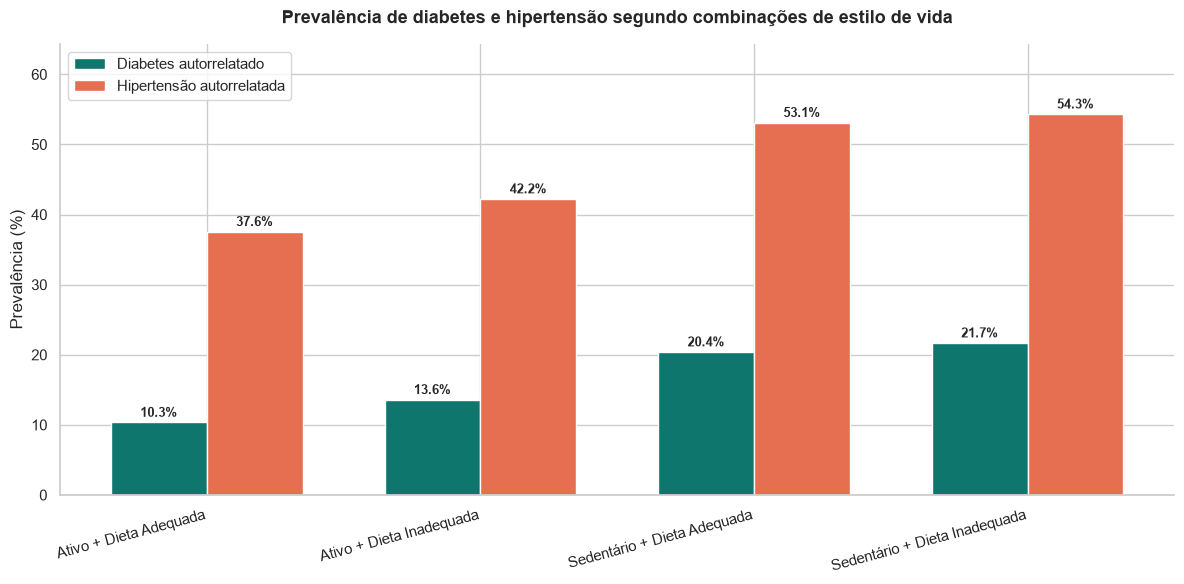

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(resumo_perfis))
largura = 0.35

barras_diab = ax.bar(x - largura/2, resumo_perfis["Prevalência de diabetes (%)"], largura, label="Diabetes autorrelatado", color="#0E766D")
barras_hiper = ax.bar(x + largura/2, resumo_perfis["Prevalência de hipertensão (%)"], largura, label="Hipertensão autorrelatada", color="#E76F51")

for bar in barras_diab:
    yval = bar.get_height()
    ax.annotate(f"{yval:.1f}%",
                (bar.get_x() + bar.get_width() / 2, yval),
                xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9, fontweight="bold")

for bar in barras_hiper:
    yval = bar.get_height()
    ax.annotate(f"{yval:.1f}%",
                (bar.get_x() + bar.get_width() / 2, yval),
                xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(resumo_perfis["Perfil_Estilo_Vida"], rotation=15, ha="right")
ax.set_ylabel("Prevalência (%)")
ax.set_ylim(0, resumo_perfis["Prevalência de hipertensão (%)"].max() + 10)
ax.set_title("Prevalência de diabetes e hipertensão segundo combinações de estilo de vida", fontsize=13, fontweight="bold", pad=15)
ax.legend(frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

In [4]:
tabela_atividade = df_eixo4.groupby("PhysActivity", observed=False).agg(
    n=("Diabetes_binary", "size"),
    Prev_Diabetes=("Diabetes_binary", lambda x: round(x.mean() * 100, 2)),
    Prev_HighBP=("HighBP", lambda x: round(x.mean() * 100, 2))
).reset_index()
tabela_atividade["Fator"] = tabela_atividade["PhysActivity"].map({0: "Inativo", 1: "Ativo"})

tabela_dieta = df_eixo4.groupby("Dieta_Adequada", observed=False).agg(
    n=("Diabetes_binary", "size"),
    Prev_Diabetes=("Diabetes_binary", lambda x: round(x.mean() * 100, 2)),
    Prev_HighBP=("HighBP", lambda x: round(x.mean() * 100, 2))
).reset_index()
tabela_dieta["Fator"] = tabela_dieta["Dieta_Adequada"].map({0: "Inadequada", 1: "Adequada"})

display(tabela_atividade[["Fator", "n", "Prev_Diabetes", "Prev_HighBP"]])
display(tabela_dieta[["Fator", "n", "Prev_Diabetes", "Prev_HighBP"]])

,Fator,n,Prev_Diabetes,Prev_HighBP
0,Inativo,61760,21.14,53.83
1,Ativo,191920,11.61,39.38


,Fator,n,Prev_Diabetes,Prev_HighBP
0,Inadequada,110968,16.21,46.15
1,Adequada,142712,12.16,40.37


In [5]:
def associacao_perfil(df, outcome_col, perfil_teste, perfil_ref="Ativo + Dieta Adequada"):
    exp = df["Perfil_Estilo_Vida"] == perfil_teste
    ref = df["Perfil_Estilo_Vida"] == perfil_ref
    dados = df.loc[exp | ref, ["Perfil_Estilo_Vida", outcome_col]].dropna()

    a = int(((dados["Perfil_Estilo_Vida"] == perfil_teste) & (dados[outcome_col] == 1)).sum())
    b = int(((dados["Perfil_Estilo_Vida"] == perfil_teste) & (dados[outcome_col] == 0)).sum())
    c = int(((dados["Perfil_Estilo_Vida"] == perfil_ref) & (dados[outcome_col] == 1)).sum())
    d = int(((dados["Perfil_Estilo_Vida"] == perfil_ref) & (dados[outcome_col] == 0)).sum())

    n1, n0 = a + b, c + d
    p1, p0 = a / n1, c / n0

    pr = p1 / p0
    se_log_pr = np.sqrt((1 / a) - (1 / n1) + (1 / c) - (1 / n0))
    pr_ic = (np.exp(np.log(pr) - 1.96 * se_log_pr), np.exp(np.log(pr) + 1.96 * se_log_pr))

    or_value, p_value = stats.fisher_exact([[a, b], [c, d]])
    se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
    or_ic = (np.exp(np.log(or_value) - 1.96 * se_log_or), np.exp(np.log(or_value) + 1.96 * se_log_or))

    return {
        "Perfil": perfil_teste,
        "n": n1,
        "Prevalência (%)": round(p1 * 100, 2),
        "PR": round(pr, 2),
        "PR IC95%": f"[{pr_ic[0]:.2f} – {pr_ic[1]:.2f}]",
        "OR": round(or_value, 2),
        "OR IC95%": f"[{or_ic[0]:.2f} – {or_ic[1]:.2f}]",
        "p-valor": f"{p_value:.3e}"
    }

resultados_eixo4 = []
for desfecho in ["Diabetes_binary", "HighBP"]:
    for perfil in ordem_perfis:
        if perfil == "Ativo + Dieta Adequada":
            continue
        r = associacao_perfil(df_eixo4, desfecho, perfil)
        r["Desfecho"] = "Diabetes" if desfecho == "Diabetes_binary" else "Hipertensão"
        resultados_eixo4.append(r)

tabela_associacoes_eixo4 = pd.DataFrame(resultados_eixo4)
tabela_associacoes_eixo4[[
    "Desfecho", "Perfil", "n", "Prevalência (%)", 
    "PR", "PR IC95%", "OR", "OR IC95%", "p-valor"
]]

,Desfecho,Perfil,n,Prevalência (%),PR,PR IC95%,OR,OR IC95%,p-valor
0,Diabetes,Ativo + Dieta Inadequada,74985,13.59,1.31,[1.28 – 1.35],1.36,[1.32 – 1.40],4.271e-102
1,Diabetes,Sedentário + Dieta Adequada,25777,20.40,1.97,[1.91 – 2.03],2.22,[2.14 – 2.30],0.000e+00
2,Diabetes,Sedentário + Dieta Inadequada,35983,21.68,2.10,[2.04 – 2.15],2.40,[2.32 – 2.47],0.000e+00
3,Hipertensão,Ativo + Dieta Inadequada,74985,42.23,1.12,[1.11 – 1.14],1.22,[1.19 – 1.24],2.019e-92
4,Hipertensão,Sedentário + Dieta Adequada,25777,53.12,1.41,[1.40 – 1.43],1.88,[1.83 – 1.94],0.000e+00
5,Hipertensão,Sedentário + Dieta Inadequada,35983,54.33,1.45,[1.43 – 1.46],1.98,[1.93 – 2.03],0.000e+00


### 4. Conclusões e Insights do Eixo 4

A análise combinada dos fatores de estilo de vida evidenciou pesos epidemiológicos consideravelmente distintos para a atividade física e a dieta:

*   **A Atividade Física como Fator Predominante:** A inatividade física associou-se a acréscimos muito mais expressivos de prevalência do que a dieta inadequada. O grupo *Ativo + Dieta Inadequada* apresentou indicadores substancialmente mais favoráveis do que o grupo *Sedentário + Dieta Adequada*.
*   **A Prática de Exercício Neutraliza a Má Alimentação?** Dentro das limitações transversais do BRFSS, a prática de atividade física regular parece atenuar a maior parte da disparidade associada ao consumo insuficiente de frutas e vegetais, mantendo as prevalências de diabetes e hipertensão muito próximas às do grupo de referência saudável (*Ativo + Dieta Adequada*).
*   **Efeito Aditivo no Sedentarismo Completo:** O perfil *Sedentário + Dieta Inadequada* concentrou os maiores riscos relativos (PR e OR com p < 0,001), sugerindo um efeito de sobreposição deletéria na ausência de ambos os comportamentos protetores.
*   **Consideração sobre as Métricas Dietéticas:** Como o BRFSS mensura apenas o consumo diário simplificado (sim/não) de frutas e vegetais, a métrica não capta a ingestão de calorias totais, gorduras saturadas ou ultraprocessados. Isso explica por que o impacto da variável dieta isolada parece mais brando do que o da atividade física.